In [1]:
#==================================================
#
# Enterprise Autocoding MLOps Platform
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

BASELINE_VERSION = "autocoder-v1"
CANDIDATE_VERSION = "autocoder-v2"

# -------------------------
# DEPLOYMENT GATES
# -------------------------

MIN_ACCURACY = 0.80
MAX_ACCURACY_REGRESSION = 0.02
MAX_F1_REGRESSION = 0.02
MAX_CLASS_REGRESSION = 0.10
MAX_NEW_REGRESSIONS = 1

# -------------------------
# HITL TARGET
# -------------------------

TARGET_AUTO_ACCEPT_ACCURACY = 0.90

# Fallback if validation data cannot
# satisfy the target.
DEFAULT_AUTO_ACCEPT_THRESHOLD = 0.70

# Anything below this gets escalated.
ESCALATE_THRESHOLD = 0.40

# -------------------------
# DRIFT
# -------------------------

DRIFT_ALPHA = 0.05

PREDICTION_DRIFT_LIMIT = 0.20
CONFIDENCE_DRIFT_LIMIT = 0.10

# Avoid treating tiny demo batches
# as statistically trustworthy.
MIN_DRIFT_SAMPLE_SIZE = 20

# -------------------------
# ARTIFACTS
# -------------------------

ARTIFACT_DIR = Path(
    "enterprise_autocoder_artifacts"
)

ARTIFACT_DIR.mkdir(
    exist_ok=True
)

print(
    "Artifact directory:",
    ARTIFACT_DIR.resolve()
)

Artifact directory: /content/enterprise_autocoder_artifacts


In [3]:
examples = {
    "SOFTWARE": [
        "Develops backend software applications",
        "Writes Python code for business systems",
        "Builds APIs and web applications",
        "Tests and maintains software products",
        "Develops cloud based applications",
        "Maintains enterprise application code",
        "Builds internal software tools",
        "Creates web services and APIs",
    ],

    "FINANCE": [
        "Analyzes financial reports and budgets",
        "Prepares company financial statements",
        "Reviews investment performance",
        "Maintains accounting records",
        "Performs financial forecasting",
        "Analyzes company expenses",
        "Prepares accounting reports",
        "Reviews budgets and financial plans",
    ],

    "HEALTHCARE": [
        "Provides medical care to patients",
        "Assists physicians with treatment",
        "Monitors patient medications",
        "Provides nursing care",
        "Supports medical procedures",
        "Works with patients in a clinic",
        "Provides hospital patient care",
        "Assists with clinical treatment",
    ],

    "EDUCATION": [
        "Teaches mathematics to students",
        "Develops classroom lessons",
        "Provides instruction to students",
        "Teaches science at a school",
        "Evaluates student assignments",
        "Creates classroom materials",
        "Provides educational instruction",
        "Teaches elementary school students",
    ],

    "TRADES": [
        "Installs electrical systems",
        "Repairs plumbing systems",
        "Performs construction work",
        "Repairs heating equipment",
        "Installs residential wiring",
        "Maintains building equipment",
        "Repairs mechanical equipment",
        "Performs building maintenance",
    ],
}

LABELS = sorted(
    examples.keys()
)

LABELS

['EDUCATION', 'FINANCE', 'HEALTHCARE', 'SOFTWARE', 'TRADES']

In [4]:
prefixes = [
    "",
    "Employee ",
    "Worker ",
    "Professional ",
]

suffixes = [
    "",
    " for customers",
    " for the organization",
    " as part of daily work",
]

rows = []

for label, texts in examples.items():

    for text in texts:

        for _ in range(6):

            rows.append({
                "text": (
                    rng.choice(prefixes)
                    + text.lower()
                    + rng.choice(suffixes)
                ),
                "label": label,
            })

data = (
    pd.DataFrame(rows)
    .drop_duplicates()
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

assert data["text"].notna().all()
assert data["label"].notna().all()
assert data["label"].nunique() == 5

print(
    "Dataset size:",
    len(data)
)

print()

print(
    data["label"].value_counts()
)

Dataset size: 209

label
SOFTWARE      44
HEALTHCARE    42
TRADES        41
FINANCE       41
EDUCATION     41
Name: count, dtype: int64


In [5]:
train_data, temp_data = train_test_split(
    data,
    test_size=0.40,
    stratify=data["label"],
    random_state=RANDOM_STATE,
)

validation_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["label"],
    random_state=RANDOM_STATE,
)

print(
    "Train:",
    len(train_data)
)

print(
    "Validation:",
    len(validation_data)
)

print(
    "Test:",
    len(test_data)
)

Train: 125
Validation: 42
Test: 42


In [6]:
golden_data = pd.DataFrame([
    (
        "Creates REST APIs for internal software services",
        "SOFTWARE"
    ),
    (
        "Maintains cloud applications used by business teams",
        "SOFTWARE"
    ),
    (
        "Debugs application code and resolves software defects",
        "SOFTWARE"
    ),
    (
        "Builds internal tools that automate business workflows",
        "SOFTWARE"
    ),

    (
        "Analyzes quarterly revenue and company expenses",
        "FINANCE"
    ),
    (
        "Creates forecasts used for corporate budgeting",
        "FINANCE"
    ),
    (
        "Reviews accounting transactions and financial records",
        "FINANCE"
    ),
    (
        "Evaluates investment performance and financial risk",
        "FINANCE"
    ),

    (
        "Provides clinical care and monitors patient health",
        "HEALTHCARE"
    ),
    (
        "Assists doctors with medical treatment procedures",
        "HEALTHCARE"
    ),
    (
        "Reviews patient medications in a healthcare setting",
        "HEALTHCARE"
    ),
    (
        "Supports patients receiving treatment in a clinic",
        "HEALTHCARE"
    ),

    (
        "Creates lesson plans for classroom instruction",
        "EDUCATION"
    ),
    (
        "Teaches students and evaluates their assignments",
        "EDUCATION"
    ),
    (
        "Provides academic instruction at an elementary school",
        "EDUCATION"
    ),
    (
        "Develops educational material for science classes",
        "EDUCATION"
    ),

    (
        "Repairs electrical equipment inside commercial buildings",
        "TRADES"
    ),
    (
        "Installs wiring and electrical components",
        "TRADES"
    ),
    (
        "Performs plumbing repairs and building maintenance",
        "TRADES"
    ),
    (
        "Services heating and mechanical equipment",
        "TRADES"
    ),

], columns=[
    "text",
    "expected_label",
])

assert len(golden_data) == 20

assert (
    golden_data[
        "expected_label"
    ].nunique()
    ==
    5
)

assert not (
    set(
        golden_data["text"].str.lower()
    )
    &
    set(
        data["text"].str.lower()
    )
)

golden_data

,text,expected_label
0,Creates REST APIs for internal software services,SOFTWARE
1,Maintains cloud applications used by business ...,SOFTWARE
2,Debugs application code and resolves software ...,SOFTWARE
3,Builds internal tools that automate business w...,SOFTWARE
4,Analyzes quarterly revenue and company expenses,FINANCE
5,Creates forecasts used for corporate budgeting,FINANCE
6,Reviews accounting transactions and financial ...,FINANCE
7,Evaluates investment performance and financial...,FINANCE
8,Provides clinical care and monitors patient he...,HEALTHCARE
9,Assists doctors with medical treatment procedures,HEALTHCARE


In [7]:
def train_autocoder(
    train_df,
    ngram_range=(1, 1),
    C=1.0,
):

    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=3000,
    )

    X_train = vectorizer.fit_transform(
        train_df["text"]
    )

    model = LogisticRegression(
        C=C,
        max_iter=500,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        train_df["label"],
    )

    return vectorizer, model

In [8]:
baseline_vectorizer, baseline_model = (
    train_autocoder(
        train_data,
        ngram_range=(1, 1),
        C=1.0,
    )
)

print(
    "Trained:",
    BASELINE_VERSION
)

Trained: autocoder-v1


In [9]:
candidate_vectorizer, candidate_model = (
    train_autocoder(
        train_data,
        ngram_range=(1, 2),
        C=1.5,
    )
)

print(
    "Trained:",
    CANDIDATE_VERSION
)

Trained: autocoder-v2


In [10]:
def evaluate_model(
    name,
    model,
    vectorizer,
    dataset,
    label_column,
):

    X = vectorizer.transform(
        dataset["text"]
    )

    predictions = model.predict(X)

    probabilities = (
        model.predict_proba(X)
    )

    confidence = (
        probabilities.max(axis=1)
    )

    expected = (
        dataset[label_column]
        .to_numpy()
    )

    accuracy = accuracy_score(
        expected,
        predictions,
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            expected,
            predictions,
            labels=LABELS,
            average="macro",
            zero_division=0,
        )
    )

    results = pd.DataFrame({
        "text":
            dataset[
                "text"
            ].to_numpy(),

        "expected_label":
            expected,

        "prediction":
            predictions,

        "confidence":
            confidence,
    })

    results["correct"] = (
        results["expected_label"]
        ==
        results["prediction"]
    )

    metrics = {
        "model":
            name,

        "accuracy":
            float(accuracy),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "f1":
            float(f1),
    }

    return metrics, results

In [11]:
baseline_metrics, baseline_results = (
    evaluate_model(
        BASELINE_VERSION,
        baseline_model,
        baseline_vectorizer,
        golden_data,
        "expected_label",
    )
)

candidate_metrics, candidate_results = (
    evaluate_model(
        CANDIDATE_VERSION,
        candidate_model,
        candidate_vectorizer,
        golden_data,
        "expected_label",
    )
)

comparison = pd.DataFrame([
    baseline_metrics,
    candidate_metrics,
]).set_index("model")

comparison

,accuracy,precision,recall,f1
model,,,,
autocoder-v1,0.95,0.96,0.95,0.949206
autocoder-v2,0.95,0.96,0.95,0.949206


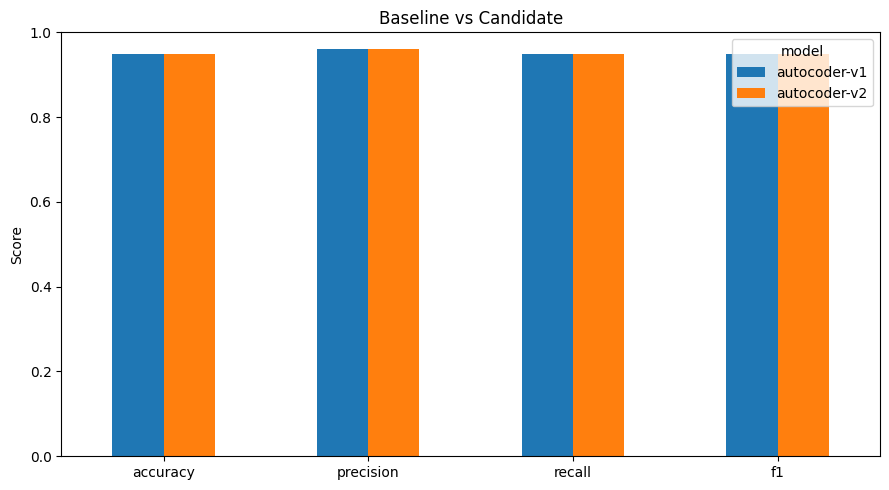

In [12]:
comparison[
    [
        "accuracy",
        "precision",
        "recall",
        "f1",
    ]
].T.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.ylabel(
    "Score"
)

plt.title(
    "Baseline vs Candidate"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [13]:
case_comparison = (
    golden_data.copy()
)

case_comparison[
    "baseline_prediction"
] = baseline_results[
    "prediction"
].to_numpy()

case_comparison[
    "candidate_prediction"
] = candidate_results[
    "prediction"
].to_numpy()

case_comparison[
    "baseline_correct"
] = baseline_results[
    "correct"
].to_numpy()

case_comparison[
    "candidate_correct"
] = candidate_results[
    "correct"
].to_numpy()

case_comparison[
    "regression"
] = (
    case_comparison[
        "baseline_correct"
    ]
    &
    ~case_comparison[
        "candidate_correct"
    ]
)

case_comparison[
    "improvement"
] = (
    ~case_comparison[
        "baseline_correct"
    ]
    &
    case_comparison[
        "candidate_correct"
    ]
)

print(
    "Regressions:",
    int(
        case_comparison[
            "regression"
        ].sum()
    )
)

print(
    "Improvements:",
    int(
        case_comparison[
            "improvement"
        ].sum()
    )
)

Regressions: 0
Improvements: 0


In [14]:
class_rows = []

for label in LABELS:

    baseline_mask = (
        baseline_results[
            "expected_label"
        ]
        ==
        label
    )

    candidate_mask = (
        candidate_results[
            "expected_label"
        ]
        ==
        label
    )

    baseline_accuracy = (
        baseline_results.loc[
            baseline_mask,
            "correct"
        ].mean()
    )

    candidate_accuracy = (
        candidate_results.loc[
            candidate_mask,
            "correct"
        ].mean()
    )

    class_rows.append({
        "class":
            label,

        "baseline_accuracy":
            float(
                baseline_accuracy
            ),

        "candidate_accuracy":
            float(
                candidate_accuracy
            ),

        "change":
            float(
                candidate_accuracy
                -
                baseline_accuracy
            ),
    })

class_comparison = pd.DataFrame(
    class_rows
)

class_comparison

,class,baseline_accuracy,candidate_accuracy,change
0,EDUCATION,1.00,1.00,0.0
1,FINANCE,0.75,0.75,0.0
2,HEALTHCARE,1.00,1.00,0.0
3,SOFTWARE,1.00,1.00,0.0
4,TRADES,1.00,1.00,0.0


In [15]:
def deployment_gate(
    baseline,
    candidate,
    class_results,
    case_results,
):

    reasons = []

    accuracy_change = (
        candidate["accuracy"]
        -
        baseline["accuracy"]
    )

    f1_change = (
        candidate["f1"]
        -
        baseline["f1"]
    )

    worst_class_change = float(
        class_results[
            "change"
        ].min()
    )

    new_regressions = int(
        case_results[
            "regression"
        ].sum()
    )

    if (
        candidate["accuracy"]
        <
        MIN_ACCURACY
    ):
        reasons.append(
            "ACCURACY_BELOW_MINIMUM"
        )

    if (
        accuracy_change
        <
        -MAX_ACCURACY_REGRESSION
    ):
        reasons.append(
            "ACCURACY_REGRESSION"
        )

    if (
        f1_change
        <
        -MAX_F1_REGRESSION
    ):
        reasons.append(
            "F1_REGRESSION"
        )

    if (
        worst_class_change
        <
        -MAX_CLASS_REGRESSION
    ):
        reasons.append(
            "CLASS_REGRESSION"
        )

    if (
        new_regressions
        >
        MAX_NEW_REGRESSIONS
    ):
        reasons.append(
            "TOO_MANY_CASE_REGRESSIONS"
        )

    return {
        "decision":
            "PASS"
            if not reasons
            else "FAIL",

        "reasons":
            reasons,

        "accuracy_change":
            float(
                accuracy_change
            ),

        "f1_change":
            float(
                f1_change
            ),

        "worst_class_change":
            worst_class_change,

        "new_regressions":
            new_regressions,
    }

In [16]:
gate_result = deployment_gate(
    baseline_metrics,
    candidate_metrics,
    class_comparison,
    case_comparison,
)

gate_result

{'decision': 'PASS',
 'reasons': [],
 'accuracy_change': 0.0,
 'f1_change': 0.0,
 'worst_class_change': 0.0,
 'new_regressions': 0}

In [17]:
if (
    gate_result["decision"]
    ==
    "PASS"
):

    production_model = (
        candidate_model
    )

    production_vectorizer = (
        candidate_vectorizer
    )

    production_version = (
        CANDIDATE_VERSION
    )

else:

    production_model = (
        baseline_model
    )

    production_vectorizer = (
        baseline_vectorizer
    )

    production_version = (
        BASELINE_VERSION
    )


print(
    "Production version:",
    production_version
)

Production version: autocoder-v2


In [18]:
test_metrics, test_results = (
    evaluate_model(
        production_version,
        production_model,
        production_vectorizer,
        test_data,
        "label",
    )
)

print(
    "Holdout accuracy:",
    f"{test_metrics['accuracy']:.2%}"
)

print()

print(
    classification_report(
        test_results[
            "expected_label"
        ],
        test_results[
            "prediction"
        ],
        labels=LABELS,
        zero_division=0,
    )
)

Holdout accuracy: 100.00%

              precision    recall  f1-score   support

   EDUCATION       1.00      1.00      1.00         8
     FINANCE       1.00      1.00      1.00         8
  HEALTHCARE       1.00      1.00      1.00         9
    SOFTWARE       1.00      1.00      1.00         9
      TRADES       1.00      1.00      1.00         8

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



In [19]:
_, validation_results = (
    evaluate_model(
        production_version,
        production_model,
        production_vectorizer,
        validation_data,
        "label",
    )
)

validation_results[
    [
        "confidence",
        "correct",
    ]
].describe()

,confidence
count,42.000000
mean,0.580583
std,0.084481
min,0.395806
25%,0.526906
50%,0.578647
75%,0.652930
max,0.772425


In [20]:
threshold_rows = []

for threshold in np.arange(
    0.40,
    0.96,
    0.05,
):

    accepted = (
        validation_results[
            "confidence"
        ]
        >=
        threshold
    )

    coverage = float(
        accepted.mean()
    )

    if accepted.any():

        accepted_accuracy = float(
            validation_results.loc[
                accepted,
                "correct"
            ].mean()
        )

    else:

        accepted_accuracy = np.nan

    threshold_rows.append({
        "threshold":
            round(
                float(threshold),
                2
            ),

        "coverage":
            coverage,

        "accuracy":
            accepted_accuracy,
    })


threshold_analysis = pd.DataFrame(
    threshold_rows
)

threshold_analysis

,threshold,coverage,accuracy
0,0.40,0.976190,1.0
1,0.45,0.904762,1.0
2,0.50,0.809524,1.0
3,0.55,0.642857,1.0
4,0.60,0.428571,1.0
5,0.65,0.285714,1.0
6,0.70,0.047619,1.0
7,0.75,0.023810,1.0
8,0.80,0.000000,NaN
9,0.85,0.000000,NaN


In [21]:
eligible_thresholds = (
    threshold_analysis[
        (
            threshold_analysis[
                "accuracy"
            ]
            >=
            TARGET_AUTO_ACCEPT_ACCURACY
        )
        &
        (
            threshold_analysis[
                "coverage"
            ]
            >
            0
        )
    ]
)

if len(eligible_thresholds):

    AUTO_ACCEPT_THRESHOLD = float(
        eligible_thresholds
        .sort_values(
            [
                "coverage",
                "threshold",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .iloc[0][
            "threshold"
        ]
    )

else:

    AUTO_ACCEPT_THRESHOLD = (
        DEFAULT_AUTO_ACCEPT_THRESHOLD
    )


if (
    AUTO_ACCEPT_THRESHOLD
    <=
    ESCALATE_THRESHOLD
):

    AUTO_ACCEPT_THRESHOLD = (
        min(
            1.0,
            ESCALATE_THRESHOLD
            +
            0.10
        )
    )


print(
    "Selected auto-accept threshold:",
    AUTO_ACCEPT_THRESHOLD
)

print(
    "Escalation threshold:",
    ESCALATE_THRESHOLD
)

Selected auto-accept threshold: 0.5
Escalation threshold: 0.4


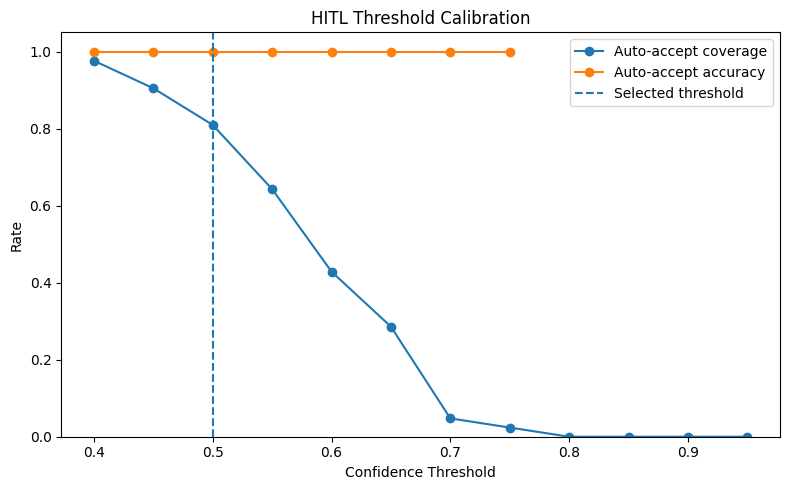

In [22]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_analysis[
        "threshold"
    ],
    threshold_analysis[
        "coverage"
    ],
    marker="o",
    label="Auto-accept coverage",
)

plt.plot(
    threshold_analysis[
        "threshold"
    ],
    threshold_analysis[
        "accuracy"
    ],
    marker="o",
    label="Auto-accept accuracy",
)

plt.axvline(
    AUTO_ACCEPT_THRESHOLD,
    linestyle="--",
    label="Selected threshold",
)

plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "Rate"
)

plt.title(
    "HITL Threshold Calibration"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.tight_layout()
plt.show()

In [23]:
def predict(text):

    X = production_vectorizer.transform(
        [text]
    )

    probabilities = (
        production_model
        .predict_proba(X)[0]
    )

    index = int(
        probabilities.argmax()
    )

    return {
        "prediction":
            str(
                production_model
                .classes_[index]
            ),

        "confidence":
            float(
                probabilities[index]
            ),
    }

In [24]:
def route_prediction(
    confidence
):

    if (
        confidence
        >=
        AUTO_ACCEPT_THRESHOLD
    ):
        return "AUTO_ACCEPT"

    if (
        confidence
        >=
        ESCALATE_THRESHOLD
    ):
        return "HUMAN_REVIEW"

    return "ESCALATE"

In [25]:
assert (
    route_prediction(
        AUTO_ACCEPT_THRESHOLD
    )
    ==
    "AUTO_ACCEPT"
)

assert (
    route_prediction(
        ESCALATE_THRESHOLD
    )
    ==
    "HUMAN_REVIEW"
)

if (
    ESCALATE_THRESHOLD
    >
    0
):

    assert (
        route_prediction(
            ESCALATE_THRESHOLD
            -
            0.01
        )
        ==
        "ESCALATE"
    )

print(
    "Routing checks passed."
)

Routing checks passed.


In [26]:
production_data = pd.DataFrame({
    "record_id": [
        "JOB-001",
        "JOB-002",
        "JOB-003",
        "JOB-004",
        "JOB-005",
        "JOB-006",
        "JOB-007",
        "JOB-008",
        "JOB-009",
        "JOB-010",
        "JOB-011",
        "JOB-012",
        "JOB-013",
        "JOB-014",
        "JOB-015",
    ],

    "text": [
        "Develops Python APIs for internal applications",
        "Provides nursing care to hospital patients",
        "Reviews company budgets and financial forecasts",
        "Installs residential electrical wiring",
        "Provides classroom instruction to students",
        "Works with technical systems and business teams",
        "Maintains building systems and equipment",
        "Supports customers using software applications",
        "Analyzes records and prepares reports",
        "Works with patients and maintains medical records",
        "Creates cloud software services",
        "Repairs mechanical building equipment",
        "Evaluates student coursework",
        "Prepares accounting reports for management",
        "Assists doctors with clinical treatment",
    ],
})

production_data

,record_id,text
0,JOB-001,Develops Python APIs for internal applications
1,JOB-002,Provides nursing care to hospital patients
2,JOB-003,Reviews company budgets and financial forecasts
3,JOB-004,Installs residential electrical wiring
4,JOB-005,Provides classroom instruction to students
5,JOB-006,Works with technical systems and business teams
6,JOB-007,Maintains building systems and equipment
7,JOB-008,Supports customers using software applications
8,JOB-009,Analyzes records and prepares reports
9,JOB-010,Works with patients and maintains medical records


In [27]:
production_rows = []

for row in production_data.itertuples(
    index=False
):

    result = predict(
        row.text
    )

    production_rows.append({
        "record_id":
            row.record_id,

        "text":
            row.text,

        "prediction":
            result[
                "prediction"
            ],

        "confidence":
            result[
                "confidence"
            ],

        "route":
            route_prediction(
                result[
                    "confidence"
                ]
            ),

        "model_version":
            production_version,
    })


production_results = pd.DataFrame(
    production_rows
)

production_results

,record_id,text,prediction,confidence,route,model_version
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.624765,AUTO_ACCEPT,autocoder-v2
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.687328,AUTO_ACCEPT,autocoder-v2
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.762347,AUTO_ACCEPT,autocoder-v2
3,JOB-004,Installs residential electrical wiring,TRADES,0.680274,AUTO_ACCEPT,autocoder-v2
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.830320,AUTO_ACCEPT,autocoder-v2
5,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.323583,ESCALATE,autocoder-v2
6,JOB-007,Maintains building systems and equipment,TRADES,0.652321,AUTO_ACCEPT,autocoder-v2
7,JOB-008,Supports customers using software applications,SOFTWARE,0.539719,AUTO_ACCEPT,autocoder-v2
8,JOB-009,Analyzes records and prepares reports,FINANCE,0.679020,AUTO_ACCEPT,autocoder-v2
9,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.464002,HUMAN_REVIEW,autocoder-v2


In [28]:
review_queue = (
    production_results[
        production_results[
            "route"
        ].isin([
            "HUMAN_REVIEW",
            "ESCALATE",
        ])
    ]
    .copy()
)

priority = {
    "ESCALATE": 0,
    "HUMAN_REVIEW": 1,
}

review_queue[
    "priority"
] = review_queue[
    "route"
].map(priority)

review_queue[
    "review_status"
] = "PENDING"

review_queue = (
    review_queue
    .sort_values(
        [
            "priority",
            "confidence",
        ]
    )
    .reset_index(drop=True)
)

review_queue

,record_id,text,prediction,confidence,route,model_version,priority,review_status
0,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.323583,ESCALATE,autocoder-v2,0,PENDING
1,JOB-013,Evaluates student coursework,EDUCATION,0.395990,ESCALATE,autocoder-v2,0,PENDING
2,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.464002,HUMAN_REVIEW,autocoder-v2,1,PENDING


In [29]:
human_labels = {
    "JOB-006": "SOFTWARE",
    "JOB-007": "TRADES",
    "JOB-008": "SOFTWARE",
    "JOB-009": "FINANCE",
    "JOB-010": "HEALTHCARE",
}

In [30]:
VALID_LABELS = set(
    LABELS
)


def review_record(
    record_id,
    reviewer_label,
    reviewer_id="reviewer-001",
):

    if (
        reviewer_label
        not in
        VALID_LABELS
    ):

        raise ValueError(
            f"Invalid label: "
            f"{reviewer_label}"
        )

    matches = review_queue[
        review_queue[
            "record_id"
        ]
        ==
        record_id
    ]

    if matches.empty:

        raise ValueError(
            f"{record_id} "
            "is not in the review queue."
        )

    row = matches.iloc[0]

    return {
        "record_id":
            record_id,

        "text":
            row["text"],

        "model_prediction":
            row["prediction"],

        "model_confidence":
            float(
                row["confidence"]
            ),

        "reviewer_label":
            reviewer_label,

        "corrected":
            bool(
                reviewer_label
                !=
                row["prediction"]
            ),

        "reviewer_id":
            reviewer_id,

        "reviewed_at":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "model_version":
            production_version,
    }

In [31]:
reviews = []

for record_id in review_queue[
    "record_id"
]:

    if (
        record_id
        in
        human_labels
    ):

        reviews.append(
            review_record(
                record_id,
                human_labels[
                    record_id
                ],
            )
        )


review_log = pd.DataFrame(
    reviews,
    columns=[
        "record_id",
        "text",
        "model_prediction",
        "model_confidence",
        "reviewer_label",
        "corrected",
        "reviewer_id",
        "reviewed_at",
        "model_version",
    ],
)

review_log

,record_id,text,model_prediction,model_confidence,reviewer_label,corrected,reviewer_id,reviewed_at,model_version
0,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.323583,SOFTWARE,True,reviewer-001,2026-09-28T19:50:41.715425+00:00,autocoder-v2
1,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.464002,HEALTHCARE,False,reviewer-001,2026-09-28T19:50:41.716233+00:00,autocoder-v2


In [32]:
final_results = (
    production_results.copy()
)

needs_review = (
    final_results[
        "route"
    ].isin([
        "HUMAN_REVIEW",
        "ESCALATE",
    ])
)

final_results[
    "final_label"
] = final_results[
    "prediction"
]

final_results[
    "decision_source"
] = "MODEL"

final_results.loc[
    needs_review,
    "final_label"
] = None

final_results.loc[
    needs_review,
    "decision_source"
] = "PENDING_REVIEW"


for review in review_log.itertuples(
    index=False
):

    mask = (
        final_results[
            "record_id"
        ]
        ==
        review.record_id
    )

    final_results.loc[
        mask,
        "final_label"
    ] = (
        review.reviewer_label
    )

    final_results.loc[
        mask,
        "decision_source"
    ] = "HUMAN"


final_results

,record_id,text,prediction,confidence,route,model_version,final_label,decision_source
0,JOB-001,Develops Python APIs for internal applications,SOFTWARE,0.624765,AUTO_ACCEPT,autocoder-v2,SOFTWARE,MODEL
1,JOB-002,Provides nursing care to hospital patients,HEALTHCARE,0.687328,AUTO_ACCEPT,autocoder-v2,HEALTHCARE,MODEL
2,JOB-003,Reviews company budgets and financial forecasts,FINANCE,0.762347,AUTO_ACCEPT,autocoder-v2,FINANCE,MODEL
3,JOB-004,Installs residential electrical wiring,TRADES,0.680274,AUTO_ACCEPT,autocoder-v2,TRADES,MODEL
4,JOB-005,Provides classroom instruction to students,EDUCATION,0.830320,AUTO_ACCEPT,autocoder-v2,EDUCATION,MODEL
5,JOB-006,Works with technical systems and business teams,HEALTHCARE,0.323583,ESCALATE,autocoder-v2,SOFTWARE,HUMAN
6,JOB-007,Maintains building systems and equipment,TRADES,0.652321,AUTO_ACCEPT,autocoder-v2,TRADES,MODEL
7,JOB-008,Supports customers using software applications,SOFTWARE,0.539719,AUTO_ACCEPT,autocoder-v2,SOFTWARE,MODEL
8,JOB-009,Analyzes records and prepares reports,FINANCE,0.679020,AUTO_ACCEPT,autocoder-v2,FINANCE,MODEL
9,JOB-010,Works with patients and maintains medical records,HEALTHCARE,0.464002,HUMAN_REVIEW,autocoder-v2,HEALTHCARE,HUMAN


In [33]:
total_records = len(
    production_results
)

auto_accepted = int(
    (
        production_results[
            "route"
        ]
        ==
        "AUTO_ACCEPT"
    ).sum()
)

review_required = int(
    production_results[
        "route"
    ].isin([
        "HUMAN_REVIEW",
        "ESCALATE",
    ]).sum()
)

escalated = int(
    (
        production_results[
            "route"
        ]
        ==
        "ESCALATE"
    ).sum()
)

reviews_completed = int(
    len(review_log)
)

pending_reviews = int(
    (
        final_results[
            "decision_source"
        ]
        ==
        "PENDING_REVIEW"
    ).sum()
)

correction_rate = (
    float(
        review_log[
            "corrected"
        ].mean()
    )
    if len(review_log)
    else 0.0
)

print(
    "Total records:",
    total_records
)

print(
    "Auto accepted:",
    auto_accepted
)

print(
    "Review required:",
    review_required
)

print(
    "Escalated:",
    escalated
)

print(
    "Reviews completed:",
    reviews_completed
)

print(
    "Pending reviews:",
    pending_reviews
)

print(
    "Correction rate:",
    f"{correction_rate:.2%}"
)

Total records: 15
Auto accepted: 12
Review required: 3
Escalated: 2
Reviews completed: 2
Pending reviews: 1
Correction rate: 50.00%


In [34]:
evaluation_candidates = (
    review_log[
        [
            "text",
            "reviewer_label",
        ]
    ]
    .rename(
        columns={
            "reviewer_label":
                "expected_label"
        }
    )
    .drop_duplicates(
        subset=["text"]
    )
    .reset_index(drop=True)
)

evaluation_candidates

,text,expected_label
0,Works with technical systems and business teams,SOFTWARE
1,Works with patients and maintains medical records,HEALTHCARE


In [35]:
next_golden_dataset = (
    pd.concat(
        [
            golden_data,
            evaluation_candidates,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=["text"],
        keep="last",
    )
    .reset_index(drop=True)
)

print(
    "Current golden cases:",
    len(golden_data)
)

print(
    "Next golden cases:",
    len(next_golden_dataset)
)

Current golden cases: 20
Next golden cases: 22


In [36]:
reference_X = (
    production_vectorizer
    .transform(
        validation_data[
            "text"
        ]
    )
)

reference_predictions = (
    production_model.predict(
        reference_X
    )
)

reference_probabilities = (
    production_model.predict_proba(
        reference_X
    )
)

reference_confidence = (
    reference_probabilities.max(
        axis=1
    )
)

reference_distribution = (
    pd.Series(
        reference_predictions
    )
    .value_counts(
        normalize=True
    )
    .reindex(
        LABELS,
        fill_value=0.0
    )
)

reference_distribution

,proportion
EDUCATION,0.190476
FINANCE,0.190476
HEALTHCARE,0.190476
SOFTWARE,0.214286
TRADES,0.214286


In [37]:
production_confidence = (
    production_results[
        "confidence"
    ].to_numpy()
)

production_distribution = (
    production_results[
        "prediction"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        LABELS,
        fill_value=0.0
    )
)

production_distribution

,proportion
prediction,
EDUCATION,0.133333
FINANCE,0.200000
HEALTHCARE,0.266667
SOFTWARE,0.200000
TRADES,0.200000


In [38]:
prediction_distance = float(
    0.5
    *
    np.abs(
        reference_distribution
        -
        production_distribution
    ).sum()
)

prediction_drift = (
    prediction_distance
    >
    PREDICTION_DRIFT_LIMIT
)

print(
    "Prediction distance:",
    round(
        prediction_distance,
        4
    )
)

print(
    "Prediction drift:",
    prediction_drift
)

Prediction distance: 0.0857
Prediction drift: False


In [39]:
confidence_mean_change = float(
    abs(
        reference_confidence.mean()
        -
        production_confidence.mean()
    )
)

if (
    len(production_confidence)
    >=
    MIN_DRIFT_SAMPLE_SIZE
):

    confidence_ks_stat, confidence_p_value = (
        ks_2samp(
            reference_confidence,
            production_confidence,
        )
    )

    confidence_drift = bool(
        confidence_p_value
        <
        DRIFT_ALPHA
        and
        confidence_mean_change
        >
        CONFIDENCE_DRIFT_LIMIT
    )

else:

    confidence_ks_stat = None
    confidence_p_value = None
    confidence_drift = False


print(
    "Mean confidence change:",
    f"{confidence_mean_change:.2%}"
)

print(
    "Confidence drift:",
    confidence_drift
)

if (
    len(production_confidence)
    <
    MIN_DRIFT_SAMPLE_SIZE
):

    print(
        "Statistical confidence drift "
        "suppressed: production sample "
        "is too small."
    )

Mean confidence change: 4.32%
Confidence drift: False
Statistical confidence drift suppressed: production sample is too small.


In [40]:
reference_known_terms = np.asarray(
    (
        reference_X
        !=
        0
    ).sum(
        axis=1
    )
).ravel()

production_X = (
    production_vectorizer
    .transform(
        production_data[
            "text"
        ]
    )
)

production_known_terms = np.asarray(
    (
        production_X
        !=
        0
    ).sum(
        axis=1
    )
).ravel()

feature_mean_change = float(
    abs(
        reference_known_terms.mean()
        -
        production_known_terms.mean()
    )
)

if (
    len(production_known_terms)
    >=
    MIN_DRIFT_SAMPLE_SIZE
):

    feature_ks_stat, feature_p_value = (
        ks_2samp(
            reference_known_terms,
            production_known_terms,
        )
    )

    feature_drift = bool(
        feature_p_value
        <
        DRIFT_ALPHA
    )

else:

    feature_ks_stat = None
    feature_p_value = None
    feature_drift = False


print(
    "Reference known terms:",
    round(
        float(
            reference_known_terms.mean()
        ),
        2
    )
)

print(
    "Production known terms:",
    round(
        float(
            production_known_terms.mean()
        ),
        2
    )
)

print(
    "Feature drift:",
    feature_drift
)

Reference known terms: 12.52
Production known terms: 6.2
Feature drift: False


In [41]:
if len(review_log):

    reviewed_model_accuracy = float(
        (
            review_log[
                "model_prediction"
            ]
            ==
            review_log[
                "reviewer_label"
            ]
        ).mean()
    )

else:

    reviewed_model_accuracy = None


print(
    "Reviewed traffic accuracy:",
    (
        f"{reviewed_model_accuracy:.2%}"
        if reviewed_model_accuracy
        is not None
        else "N/A"
    )
)

Reviewed traffic accuracy: 50.00%


In [42]:
drift_alerts = []

if prediction_drift:

    drift_alerts.append(
        "PREDICTION_DRIFT"
    )

if confidence_drift:

    drift_alerts.append(
        "CONFIDENCE_DRIFT"
    )

if feature_drift:

    drift_alerts.append(
        "FEATURE_DRIFT"
    )


drift_report = {
    "status":
        (
            "DRIFT"
            if drift_alerts
            else "HEALTHY"
        ),

    "alerts":
        drift_alerts,

    "production_sample_size":
        int(
            len(
                production_results
            )
        ),

    "prediction_distance":
        prediction_distance,

    "confidence_mean_change":
        confidence_mean_change,

    "confidence_ks_p_value":
        (
            float(
                confidence_p_value
            )
            if confidence_p_value
            is not None
            else None
        ),

    "feature_mean_change":
        feature_mean_change,

    "feature_ks_p_value":
        (
            float(
                feature_p_value
            )
            if feature_p_value
            is not None
            else None
        ),

    "reviewed_model_accuracy":
        reviewed_model_accuracy,
}

drift_report

{'status': 'HEALTHY',
 'alerts': [],
 'production_sample_size': 15,
 'prediction_distance': 0.0857142857142857,
 'confidence_mean_change': 0.04315239921731984,
 'confidence_ks_p_value': None,
 'feature_mean_change': 6.3238095238095235,
 'feature_ks_p_value': None,
 'reviewed_model_accuracy': 0.5}

In [43]:
dashboard = pd.DataFrame({
    "metric": [
        "Holdout Accuracy",
        "Production Mean Confidence",
        "Auto Accept Rate",
        "Review Rate",
        "Escalation Rate",
        "Correction Rate",
        "Prediction Drift Distance",
    ],

    "value": [
        test_metrics[
            "accuracy"
        ],

        production_results[
            "confidence"
        ].mean(),

        (
            auto_accepted
            /
            total_records
        ),

        (
            review_required
            /
            total_records
        ),

        (
            escalated
            /
            total_records
        ),

        correction_rate,

        prediction_distance,
    ],
})

dashboard

,metric,value
0,Holdout Accuracy,1.000000
1,Production Mean Confidence,0.623735
2,Auto Accept Rate,0.800000
3,Review Rate,0.200000
4,Escalation Rate,0.133333
5,Correction Rate,0.500000
6,Prediction Drift Distance,0.085714


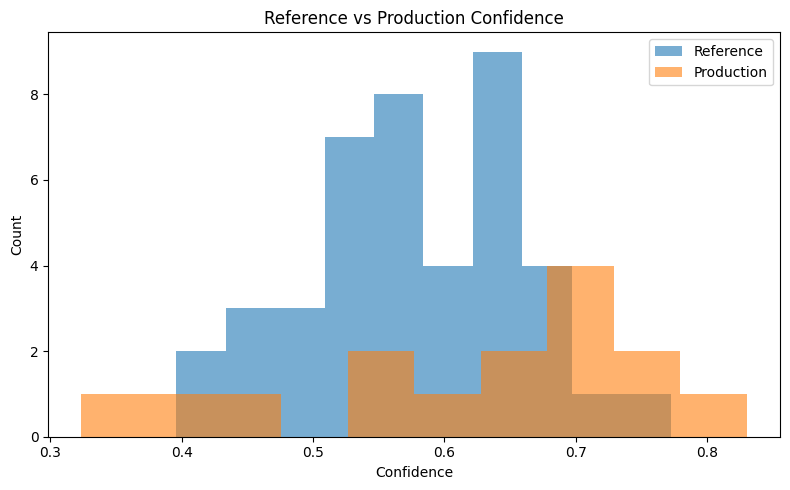

In [44]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    reference_confidence,
    alpha=0.6,
    label="Reference",
)

plt.hist(
    production_confidence,
    alpha=0.6,
    label="Production",
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Reference vs Production Confidence"
)

plt.legend()

plt.tight_layout()
plt.show()

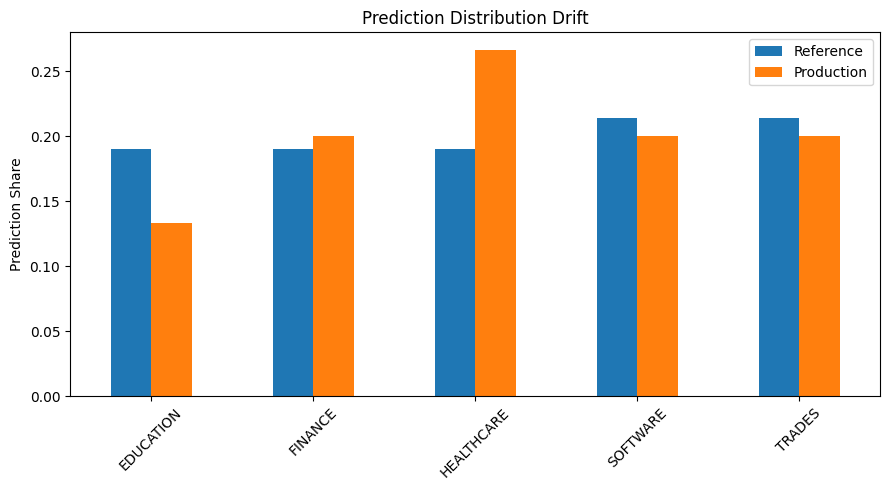

In [45]:
distribution_plot = pd.DataFrame({
    "Reference":
        reference_distribution,

    "Production":
        production_distribution,
})

distribution_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.ylabel(
    "Prediction Share"
)

plt.title(
    "Prediction Distribution Drift"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

In [46]:
MODEL_PATH = (
    ARTIFACT_DIR
    /
    "production_autocoder.joblib"
)

joblib.dump(
    {
        "model":
            production_model,

        "vectorizer":
            production_vectorizer,

        "model_version":
            production_version,

        "labels":
            LABELS,

        "auto_accept_threshold":
            AUTO_ACCEPT_THRESHOLD,

        "escalate_threshold":
            ESCALATE_THRESHOLD,
    },
    MODEL_PATH,
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: enterprise_autocoder_artifacts/production_autocoder.joblib


In [47]:
EVALUATION_PATH = (
    ARTIFACT_DIR
    /
    "evaluation_report.json"
)

CASE_RESULTS_PATH = (
    ARTIFACT_DIR
    /
    "regression_cases.csv"
)

CLASS_RESULTS_PATH = (
    ARTIFACT_DIR
    /
    "class_results.csv"
)


evaluation_report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "baseline":
        baseline_metrics,

    "candidate":
        candidate_metrics,

    "deployment_gate":
        gate_result,

    "production_version":
        production_version,

    "holdout_test":
        test_metrics,
}


with open(
    EVALUATION_PATH,
    "w"
) as file:

    json.dump(
        evaluation_report,
        file,
        indent=4,
    )


case_comparison.to_csv(
    CASE_RESULTS_PATH,
    index=False,
)

class_comparison.to_csv(
    CLASS_RESULTS_PATH,
    index=False,
)

In [48]:
REVIEW_QUEUE_PATH = (
    ARTIFACT_DIR
    /
    "review_queue.csv"
)

REVIEW_LOG_PATH = (
    ARTIFACT_DIR
    /
    "review_log.csv"
)

FINAL_RESULTS_PATH = (
    ARTIFACT_DIR
    /
    "final_results.csv"
)

FEEDBACK_PATH = (
    ARTIFACT_DIR
    /
    "evaluation_candidates.csv"
)

NEXT_GOLDEN_PATH = (
    ARTIFACT_DIR
    /
    "next_golden_dataset.csv"
)


review_queue.to_csv(
    REVIEW_QUEUE_PATH,
    index=False,
)

review_log.to_csv(
    REVIEW_LOG_PATH,
    index=False,
)

final_results.to_csv(
    FINAL_RESULTS_PATH,
    index=False,
)

evaluation_candidates.to_csv(
    FEEDBACK_PATH,
    index=False,
)

next_golden_dataset.to_csv(
    NEXT_GOLDEN_PATH,
    index=False,
)

In [49]:
DRIFT_PATH = (
    ARTIFACT_DIR
    /
    "drift_report.json"
)

with open(
    DRIFT_PATH,
    "w"
) as file:

    json.dump(
        {
            "timestamp":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "model_version":
                production_version,

            **drift_report,
        },
        file,
        indent=4,
    )

In [50]:
AUDIT_PATH = (
    ARTIFACT_DIR
    /
    "production_audit.json"
)


audit_report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model_version":
        production_version,

    "deployment": {
        "candidate":
            CANDIDATE_VERSION,

        "gate_decision":
            gate_result[
                "decision"
            ],

        "production_version":
            production_version,
    },

    "quality": {
        "golden_accuracy":
            (
                candidate_metrics[
                    "accuracy"
                ]
                if production_version
                ==
                CANDIDATE_VERSION
                else baseline_metrics[
                    "accuracy"
                ]
            ),

        "holdout_accuracy":
            test_metrics[
                "accuracy"
            ],

        "holdout_f1":
            test_metrics[
                "f1"
            ],
    },

    "hitl": {
        "auto_accept_threshold":
            AUTO_ACCEPT_THRESHOLD,

        "escalate_threshold":
            ESCALATE_THRESHOLD,

        "total_records":
            total_records,

        "auto_accepted":
            auto_accepted,

        "review_required":
            review_required,

        "reviews_completed":
            reviews_completed,

        "pending_reviews":
            pending_reviews,

        "correction_rate":
            correction_rate,
    },

    "monitoring":
        drift_report,

    "feedback": {
        "new_evaluation_candidates":
            int(
                len(
                    evaluation_candidates
                )
            ),

        "next_golden_size":
            int(
                len(
                    next_golden_dataset
                )
            ),
    },
}


with open(
    AUDIT_PATH,
    "w"
) as file:

    json.dump(
        audit_report,
        file,
        indent=4,
    )


audit_report

{'timestamp': '2026-09-28T19:50:43.436207+00:00',
 'model_version': 'autocoder-v2',
 'deployment': {'candidate': 'autocoder-v2',
  'gate_decision': 'PASS',
  'production_version': 'autocoder-v2'},
 'quality': {'golden_accuracy': 0.95,
  'holdout_accuracy': 1.0,
  'holdout_f1': 1.0},
 'hitl': {'auto_accept_threshold': 0.5,
  'escalate_threshold': 0.4,
  'total_records': 15,
  'auto_accepted': 12,
  'review_required': 3,
  'reviews_completed': 2,
  'pending_reviews': 1,
  'correction_rate': 0.5},
 'monitoring': {'status': 'HEALTHY',
  'alerts': [],
  'production_sample_size': 15,
  'prediction_distance': 0.0857142857142857,
  'confidence_mean_change': 0.04315239921731984,
  'confidence_ks_p_value': None,
  'feature_mean_change': 6.3238095238095235,
  'feature_ks_p_value': None,
  'reviewed_model_accuracy': 0.5},
 'feedback': {'new_evaluation_candidates': 2, 'next_golden_size': 22}}

In [51]:
def promotion_check(
    fail_on_error=False
):

    passed = (
        gate_result[
            "decision"
        ]
        ==
        "PASS"
    )

    if (
        not passed
        and
        fail_on_error
    ):

        raise RuntimeError(
            "Deployment blocked: "
            +
            ", ".join(
                gate_result[
                    "reasons"
                ]
            )
        )

    return passed


if promotion_check():

    print(
        "Candidate passed deployment gate."
    )

else:

    print(
        "Candidate blocked."
    )

    print(
        gate_result[
            "reasons"
        ]
    )

Candidate passed deployment gate.


In [52]:
loaded_artifact = joblib.load(
    MODEL_PATH
)

loaded_model = (
    loaded_artifact[
        "model"
    ]
)

loaded_vectorizer = (
    loaded_artifact[
        "vectorizer"
    ]
)

print(
    "Loaded:",
    loaded_artifact[
        "model_version"
    ]
)

print(
    "Auto-accept threshold:",
    loaded_artifact[
        "auto_accept_threshold"
    ]
)

Loaded: autocoder-v2
Auto-accept threshold: 0.5


In [53]:
def smoke_test():

    # -------------------------
    # DATA
    # -------------------------

    assert (
        data[
            "label"
        ].nunique()
        ==
        5
    )

    assert (
        golden_data[
            "expected_label"
        ].nunique()
        ==
        5
    )

    # -------------------------
    # MODEL EVALUATION
    # -------------------------

    for metrics in [
        baseline_metrics,
        candidate_metrics,
        test_metrics,
    ]:

        for metric in [
            "accuracy",
            "precision",
            "recall",
            "f1",
        ]:

            assert (
                0
                <=
                metrics[metric]
                <=
                1
            )

    # -------------------------
    # DEPLOYMENT
    # -------------------------

    assert (
        gate_result[
            "decision"
        ]
        in {
            "PASS",
            "FAIL",
        }
    )

    expected_version = (
        CANDIDATE_VERSION
        if gate_result[
            "decision"
        ]
        ==
        "PASS"
        else BASELINE_VERSION
    )

    assert (
        production_version
        ==
        expected_version
    )

    # -------------------------
    # HITL
    # -------------------------

    assert (
        0
        <=
        ESCALATE_THRESHOLD
        <
        AUTO_ACCEPT_THRESHOLD
        <=
        1
    )

    valid_routes = {
        "AUTO_ACCEPT",
        "HUMAN_REVIEW",
        "ESCALATE",
    }

    assert set(
        production_results[
            "route"
        ]
    ).issubset(
        valid_routes
    )

    pending = (
        final_results[
            "decision_source"
        ]
        ==
        "PENDING_REVIEW"
    )

    assert (
        final_results.loc[
            pending,
            "final_label"
        ]
        .isna()
        .all()
    )

    # -------------------------
    # HUMAN OVERRIDES
    # -------------------------

    for review in review_log.itertuples(
        index=False
    ):

        row = (
            final_results[
                final_results[
                    "record_id"
                ]
                ==
                review.record_id
            ]
            .iloc[0]
        )

        assert (
            row[
                "final_label"
            ]
            ==
            review.reviewer_label
        )

        assert (
            row[
                "decision_source"
            ]
            ==
            "HUMAN"
        )

    # -------------------------
    # FEEDBACK
    # -------------------------

    assert set(
        next_golden_dataset.columns
    ) == {
        "text",
        "expected_label",
    }

    assert (
        len(
            next_golden_dataset
        )
        >=
        len(
            golden_data
        )
    )

    # -------------------------
    # DRIFT
    # -------------------------

    assert (
        drift_report[
            "status"
        ]
        in {
            "HEALTHY",
            "DRIFT",
        }
    )

    assert (
        0
        <=
        prediction_distance
        <=
        1
    )

    # -------------------------
    # ARTIFACTS
    # -------------------------

    required_paths = [
        MODEL_PATH,
        EVALUATION_PATH,
        CASE_RESULTS_PATH,
        CLASS_RESULTS_PATH,
        REVIEW_QUEUE_PATH,
        REVIEW_LOG_PATH,
        FINAL_RESULTS_PATH,
        FEEDBACK_PATH,
        NEXT_GOLDEN_PATH,
        DRIFT_PATH,
        AUDIT_PATH,
    ]

    assert all(
        path.exists()
        for path in required_paths
    )

    # -------------------------
    # MODEL RELOAD
    # -------------------------

    sample = (
        "Develops Python software"
    )

    original_prediction = (
        production_model.predict(
            production_vectorizer.transform(
                [sample]
            )
        )[0]
    )

    loaded_prediction = (
        loaded_model.predict(
            loaded_vectorizer.transform(
                [sample]
            )
        )[0]
    )

    assert (
        original_prediction
        ==
        loaded_prediction
    )

    assert (
        loaded_artifact[
            "model_version"
        ]
        ==
        production_version
    )

    # -------------------------
    # DONE
    # -------------------------

    print(
        "Enterprise Autocoding "
        "MLOps Platform: PASS"
    )


smoke_test()

Enterprise Autocoding MLOps Platform: PASS


In [54]:
print(
    "=" * 55
)

print(
    "ENTERPRISE AUTOCODING MLOPS PLATFORM"
)

print(
    "=" * 55
)

print(
    f"Candidate:        {CANDIDATE_VERSION}"
)

print(
    f"Deployment gate:  {gate_result['decision']}"
)

print(
    f"Production model: {production_version}"
)

print(
    f"Golden accuracy:  "
    f"{candidate_metrics['accuracy']:.2%}"
)

print(
    f"Holdout accuracy: "
    f"{test_metrics['accuracy']:.2%}"
)

print(
    f"Auto threshold:   "
    f"{AUTO_ACCEPT_THRESHOLD:.2f}"
)

print(
    f"Auto accepted:    "
    f"{auto_accepted}/{total_records}"
)

print(
    f"Human reviews:    "
    f"{reviews_completed}/{review_required}"
)

print(
    f"Corrections:      "
    f"{correction_rate:.2%}"
)

print(
    f"Drift status:     "
    f"{drift_report['status']}"
)

print(
    f"Feedback cases:   "
    f"{len(evaluation_candidates)}"
)

print(
    "=" * 55
)

ENTERPRISE AUTOCODING MLOPS PLATFORM
Candidate:        autocoder-v2
Deployment gate:  PASS
Production model: autocoder-v2
Golden accuracy:  95.00%
Holdout accuracy: 100.00%
Auto threshold:   0.50
Auto accepted:    12/15
Human reviews:    2/3
Corrections:      50.00%
Drift status:     HEALTHY
Feedback cases:   2
